# Neural Computing Assignment

This assignment will introduce you to train various neural network architectures on the EMNIST dataset to classify numbers and letters. You will also perform a hyperparameter optimization study and analyse which part of the models are responsible for various tasks. You have to implement the code and **explain and analyse it in the markdown cells below**. You should hand in:
- the finished jupyter notebook with executed cells so that we can check the outputs
- all the trained and saved models whose performance is shown in the completed notebook 

---
## Grading Criteria

### Overview

- **General Quality:** 50%  
- **Part-Specific Evaluation:** 50%

---

### 1. General Quality (50%)

- **Code Implementation (20%)**  
  Correctness, structure, and readability of the implementation.

- **Plot Quality & Analysis (20%)**  
  Clarity of visualizations and ability to extract meaningful insights.

- **Scientific Standards (10%)**  
  Proper use of data splits and sound experimental methodology.

---

### 2. Part-Specific Evaluation (50%)

- **Part 1 (10%)**  
  Correct implementation of the baseline pipeline (model, training, evaluation) and ability to reproduce expected behavior.

- **Part 2 (15%)**  
  Development and comparison of multiple models, with clear analysis of differences in performance and behavior.

- **Part 3 (15%)**  
  Improvement over baseline through informed design choices (e.g., architecture, hyperparameters), supported by evidence.

- **Part 4 (10%)**  
  Ability to generalize methods to new settings and provide clear reasoning for design decisions.

---

## Notes for Students

- Emphasis is placed on **clarity, correctness, and understanding**, not only prediction performance.  
- Well-structured code and clear explanations are essential for a high grade.  
- Plots and analysis should support your conclusions, not just be included.
---

## Setup

First of all, you will need to install the required packages. You can automatically get all the packages through uv.

If you want to automatically install them, install uv (https://docs.astral.sh/uv/getting-started/installation/)

After uv is installed, run:

`uv init` (This initialises uv in your repository and creates the virtual environment)

`uv sync` (This automatically matches your installed packages with those in pyproject.toml)

If your computer supports a cuda version other than 13.0 or does not support cuda, you may need to modify pyproject.toml. 

You are also free to install the packages any other way.

Additional remarks

- The imports below are just an example, you are free to import more libraries.
- We give some basic functions to fill up. You should use these functions and not change their names, as we will grade based on them. However, you are free (and encouraged) to add more arguments to them and add helper functions.
- If your computer supports CUDA, make sure you have PyTorch installed with CUDA, as it will significanly reduce computation time. Macs do not have CUDA, but you may be able to use mps.
- Make sure your results are reproducible and run in a reasonable time. This assignment should not require you to run a single cell for hours.

In [1]:
import torch
from torch import Tensor
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import EMNIST
import matplotlib.pyplot as plt
from torchvision.transforms import v2
import torch.optim as optim
from scipy.signal import savgol_filter
import numpy as np
import os
from addict import Dict
import optuna
import gc

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device {device}")

Using device cpu


In [2]:
# fix all seeds
torch.manual_seed(69)

## Part 1: Create a simple fully connected network

This part is a introduction how to train neural networks. You will load and investigate the **balanced** EMNIST dataset and write a training and evaluation function. For this part, we will train a simple fully connected network using the pytorch library. 

Explain below, how the balanced EMNIST dataset looks like and how the train and evaluate function works.

First you should load the EMNIST dataset, prepare it and set up the dataloader for later training. 

In [4]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor
from torch.utils.data import Subset

use_subset = True

# (Assuming they want us to used 'balanced' as the split since they say "download the balanced emnist')
EMNIST_dataset = EMNIST(root='./EMNIST', split='balanced', download=True, transform=ToTensor())
label_names = EMNIST_dataset.classes

# subset of the dataset for when testing to not have to wait a long time
EMNIST_subset = Subset(EMNIST_dataset, indices=range(100))

#batch size of 10 since thats what they ask us to show in the picture

if use_subset:
    EMNIST_dataloader = DataLoader(EMNIST_subset, batch_size=10, shuffle=True)
else:
    EMNIST_dataloader = DataLoader(EMNIST_dataset, batch_size=10, shuffle=True)

100%|██████████| 562M/562M [00:09<00:00, 61.1MB/s] 


Write code to show a overview of 10 EMNIST examples. The image shows how we plotted the EMNIST overview. Make sure that your code produces the same or very similar images as shown below (it does not have to show the exact same characters, but it needs to show some characters in the same format). You may need to do some transformations to your data.

![image.png](multiple_images_emnist.png)

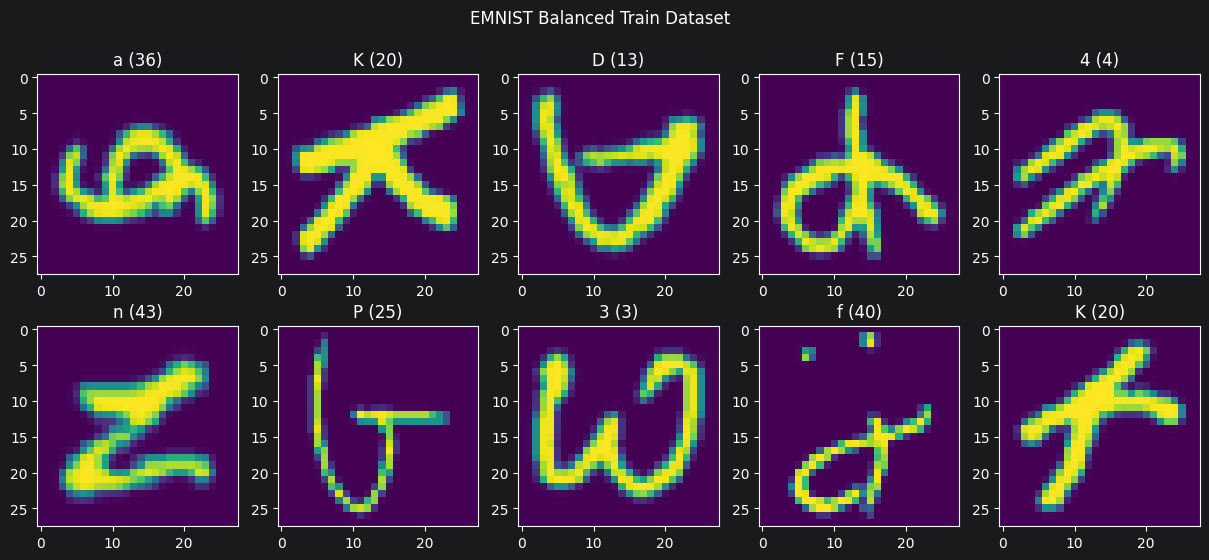

In [5]:
def show_multiple_images(data):
    
    #get first sample
    train_feat, train_lab = next(iter(EMNIST_dataloader))
    label_names = EMNIST_dataset.classes
    
    # so images are 1x28x28 and we have 10 -> a sample is a tensor of 10x1x28x28
    train_feat.size()
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    # flatter axes so that we can iterate through them linearly
    axes = axes.flatten()
    
    for img_idx in range(len(train_feat)):
        image = train_feat[img_idx]
        img_subplot = axes[img_idx]
    
        # remove the first unneeded dimension
        image = image.reshape((28, 28))
        
        img_subplot.imshow(image.numpy())
        img_subplot.set_title(f'{label_names[train_lab[img_idx]]} ({train_lab[img_idx]})')

    fig.suptitle("EMNIST Balanced Train Dataset")

show_multiple_images(EMNIST_dataloader)

Create a simple fully connected network.

In [6]:
# assuming that fully connected has only 1 hidden layer since they specify only 1 hidden size

class SimpleFCNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes) -> None:

        super().__init__()

        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.flatten(start_dim=1)

        # feedforward & then softmax
        x = F.relu(self.layer1(x))

        # im guessing we always pass batches through
        x = F.softmax(self.layer2(x), dim=1)
        return x

    # for checkpointing already trained models, since it takes a long time to run otherwise
    def save(self, path='saved_model_checkpoints/'):
        os.makedirs(path, exist_ok=True)
        
        checkpoint = {
            'model_state_dict': self.state_dict(),
            'architecture': {
                'input_size': self.layer1.in_features,
                'hidden_size': self.layer1.out_features,
                'num_classes': self.layer2.out_features
            }
        }
        filepath = os.path.join(path, 'feedforward-model.pth')
        torch.save(checkpoint, filepath)
        print(f"Model checkpoint saved to {filepath}")  

In [7]:
def evaluate(model, loader, with_print=False) -> None:
    """Method to evaluate the model on the test dataset.

    Args:
        model (nn.Module): the trained neural network model
        loader (torch.utils.data.DataLoader): the balanced EMNIST test dataset

    Returns:
        float: The accuracy

    """
    
    correct = 0
    total = len(loader.dataset)

    # we dont need gradients for eval
    with torch.no_grad():
        if with_print:
            print('')
        for idx, (images, labels) in enumerate(loader):

            if with_print:
                print(f'\rEvaluation on epoch: {idx}/{len(loader)}', end='', flush=True)
            
            outputs = model.forward(images) # 10x47 (score for each label)
            predicted_labels = torch.argmax(outputs, dim=1) # 10 number label prediction
        
            correct += (predicted_labels == labels).sum().item()
    if with_print:
        print('')
        
    accuracy = correct / total
    return accuracy


def train_one_epoch(model, train_loader, optimizer, loss_fn, with_print=False):
    """Performs a single training epoch over the entire dataset.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing
            batches of training data (images and labels).
        optimizer (torch.optim.Optimizer): The optimization algorithm used
            to update model parameters.
        loss_fn (nn.modules.loss._Loss): The loss function used to calculate
            the error.

    Returns:
        float: The cumulative loss for the entire epoch, calculated as the
            sum of losses from each individual batch.
    """

    cumulative_loss = 0.0

    # for each batch
    for idx, (images, labels) in enumerate(train_loader):

        optimizer.zero_grad()

        # pass batch through network
        outputs = model.forward(images)

        # get loss
        loss = loss_fn(outputs, labels)

        # get loss
        loss.backward()

        # update
        optimizer.step()

        cumulative_loss += loss.item()
        
        print(f'\rbatch {idx}/{len(train_loader)} loss: ' + str(loss.item()), end='')
    print('')

    return cumulative_loss


def train_num_epochs(model, train_loader, optimizer, loss_fn, num_epochs, with_checkpointing=False):
    """Training over multiple epochs. 
    This function repeatedly calls the `train_one_epoch` function, calculates the average loss per batch for each epoch, 
    and prints a progress report to the console. 
    This function shouldn't keep track of the training accuracy and is therefore more efficient than the train_with_accuracyplotting method.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing
            batches of training data.
        optimizer (torch.optim.Optimizer): The optimization algorithm (e.g., Adam or SGD).
        loss_fn (nn.modules.loss._Loss): The loss function used to evaluate model performance.
        num_epochs (int): The total number of full passes over the training dataset.
    """

    best_avg_batch_loss = float('inf')
    
    for epoch in range(num_epochs):
        # to calculate avg loss per batch for an epoch its cum_loss/num_batches
        epoch_cum_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)

        avg_batch_loss = epoch_cum_loss / len(train_loader)

        print(f'Epoch: {epoch} | avg batch loss: {avg_batch_loss}')

        if with_checkpointing and avg_batch_loss < best_avg_batch_loss:
            print('checkpointing model')


def train_num_epochs_and_track_accuracies(
    model, train_loader, test_loader, optimizer, loss_fn, num_epochs, with_checkpointing = False
):
    """Trains the model and tracks accuracy for both training and test sets.

    This function performs a full training cycle for a specified number of epochs. 
    After each training pass, it evaluates the model's performance on both the training and test datasets to monitor for convergence and overfitting.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing training data batches.
        test_loader (torch.utils.data.DataLoader): The DataLoader providing  validation/test data batches.
        optimizer (torch.optim.Optimizer): The optimization algorithm.
        loss_fn (nn.modules.loss._Loss): The loss function used for training.
        num_epochs (int): Total number of times to iterate over the dataset.

    Returns:
        tuple: A tuple containing the trained model and the accuracies
    """

    train_accuracies = []
    test_accuracies = []

    best_test_acc = 0
    
    for epoch in range(num_epochs):
        
        # to calculate avg loss per batch for an epoch its cum_loss/num_batches
        epoch_cum_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    
        avg_batch_loss = epoch_cum_loss / len(train_loader)
    
        print(f'Epoch: {epoch} | avg batch loss: {avg_batch_loss}')

        # get accuracy
        print("evaluating model")
        train_acc = evaluate(model, train_loader, with_print=False)
        test_acc = evaluate(model, test_loader, with_print=False)
        print(f"Train acc: {train_acc} | Test acc: {test_acc}")

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        if with_checkpointing and test_acc > best_test_acc:
            model.save()
            print("checkpointing model")
        
    return model, train_accuracies, test_accuracies




In [8]:
def accuracy_curve(model_name, accuracies):
    """
    Creates a line plot of the model's accuracy over the epochs. Compares the train and test accuracy of the various models
    Args:
        model_name: Str
            Name for file naming
        accuracies: List
            List of lists
            Each list is one epoch and contains train-, test- and verification accuracy
    """
    
    train_accs = [epoch[0] for epoch in accuracies]
    test_accs  = [epoch[1] for epoch in accuracies]
    epochs     = range(1, len(accuracies) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_accs, label='Train Accuracy', linewidth=2)
    plt.plot(epochs, test_accs,  label='Test Accuracy',  linewidth=2)

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy over Epochs — {model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()

batch 9023/9024 loss: 3.8475451469421387
Epoch: 0 | avg batch loss: 3.848752424543631
evaluating model
Train acc: 0.06561391843971631 | Test acc: 0.0663563829787234
Model checkpoint saved to saved_model_checkpoints/feedforward-model.pth
checkpointing model
batch 9023/9024 loss: 3.8562760353088384
Epoch: 1 | avg batch loss: 3.840004505259348
evaluating model
Train acc: 0.04688608156028369 | Test acc: 0.046586879432624115
Model checkpoint saved to saved_model_checkpoints/feedforward-model.pth
checkpointing model
batch 9023/9024 loss: 3.6112442016601562
Epoch: 2 | avg batch loss: 3.795410966830896
evaluating model
Train acc: 0.14343971631205674 | Test acc: 0.14188829787234042
Model checkpoint saved to saved_model_checkpoints/feedforward-model.pth
checkpointing model
batch 9023/9024 loss: 3.6828541755676275
Epoch: 3 | avg batch loss: 3.737774030087476
evaluating model
Train acc: 0.16869459219858157 | Test acc: 0.1656028368794326
Model checkpoint saved to saved_model_checkpoints/feedforward

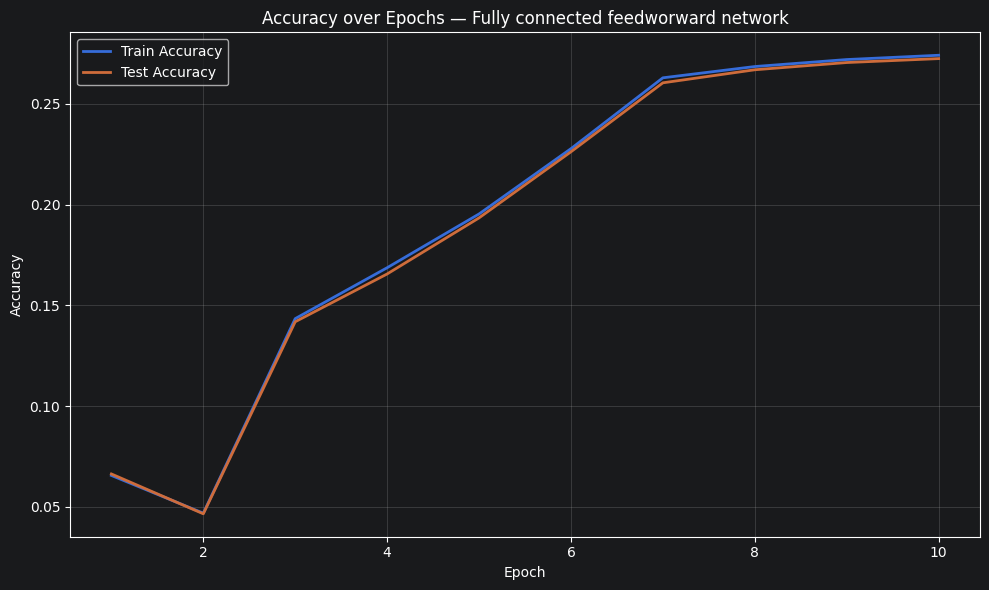

In [9]:
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor
from torch.utils.data import Subset

# load data
EMNIST_dataset = EMNIST(root='./EMNIST', split='balanced', download=False, transform=ToTensor())

#batch size of 10 since thats what they ask us to show in the picture
EMNIST_dataloader = DataLoader(EMNIST_dataset, batch_size=10, shuffle=True)

# define the train & test size splits
train_test_split = 0.8

train_size = int(train_test_split * len(EMNIST_dataset))
test_size = len(EMNIST_dataset) - train_size

train_dataset, test_dataset = random_split(EMNIST_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=10, shuffle=False)

# load model
load_checkpoint = False
if load_checkpoint:
    checkpoint = torch.load('saved_model_checkpoints/feedforward-model.pth')
    arch = checkpoint['architecture']
    model = SimpleFCNetwork(arch['input_size'], arch['hidden_size'], arch['num_classes'])
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model = SimpleFCNetwork(28*28, 64, len(label_names))

optimizer = optim.SGD(model.parameters(), lr=0.01)
loss = nn.CrossEntropyLoss()

model, train_accs, test_accs = train_num_epochs_and_track_accuracies(model=model, 
                                                                     train_loader=train_loader, 
                                                                     test_loader=test_loader, 
                                                                     optimizer=optimizer, 
                                                                     loss_fn=loss, 
                                                                     num_epochs=10,
                                                                     with_checkpointing=True)

#print("prev acc: " + str(prev_acc))
#print("new acc: " + str(evaluate(model, EMNIST_dataloader)))

accuracy_curve("Fully connected feedworward network", list(zip(train_accs, test_accs)))

### 🖊️📜 (200 words max)

Explain here:
- How the EMNIST dataset looks like.
- The structure of the network.

# Part 2: Implement and compare additional Neural Network architectures
In this task you will have to research four different neural network architectures and implement them in this notebook. Explain the structure of those architectures below! Train those model architectures on the EMNIST dataset and compare their accuracies below. Think of a smart way to compare the networks visually in a plot, such as taught in one of the lectures. Also pay attention on which models might be overfitting.

In [10]:
class CNN_SMALL(nn.Module):
    def __init__(self, num_classes=47):
        """
        Basic convolutional neural network
            input layer:
            hidden layer:
            output layer: for EMNIST 100

        Args:
            num_classes: int
                The number of classes we want to predict
        """
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)  # -> 32x28x28
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # -> 64x14x14
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)                                 # halves spatial dims

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        """
        Define the forward pass of the neural network.

        Args:
            x: torch.Tensor
                The input tensor.

        Returns:
            torch.Tensor
                The output tensor after passing through the network.
        """
        # handle both (N, 28, 28) and (N, 1, 28, 28) inputs
        if x.dim() == 3:
            x = x.unsqueeze(1)           # -> (N, 1, 28, 28)

        x = self.pool(F.relu(self.conv1(x)))  # -> (N, 32, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))  # -> (N, 64,  7,  7)

        # flatten everything
        x = x.view(x.size(0), -1)            # -> (N, 64*7*7)

        x = F.relu(self.fc1(x))              # -> (N, 256)
        x = self.fc2(x)                      # -> (N, num_classes)

        return x

In [22]:
class CNN_BIG(nn.Module):
    def __init__(self, num_classes=47):
        """
        Advanced convolutional neural network
            input layer:
            hidden layer:
            output layer: for EMNIST 100
        Args:
            num_classes: int
                The number of classes we want to predict
        """
        super().__init__()
        
        # 1x28x28 -> 32x28x28 -> 32x14x14
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # normalize outputs

        # 32x14x14 -> 64x14x14 -> 64x7x7
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) # normalize outputs

        # 64x7x7 -> 128x7x7 -> 128x3x3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) # normalize outputs

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 128 * 3 * 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        """
        Define the forward pass of the neural network.
        Args:
            x: torch.Tensor
                The input tensor.
        Returns:
            torch.Tensor
                The output tensor after passing through the network.
        """
        
        # handle both (N, 28, 28) and (N, 1, 28, 28) inputs
        if x.dim() == 3:
            x = x.unsqueeze(1)                         # (N, 1,   28, 28)

        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # (N, 32,  14, 14)
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # (N, 64,   7,  7)
        x = self.pool(F.relu(self.bn3(self.conv3(x)))) # (N, 128,  3,  3)

        x = x.view(x.size(0), -1)                      # (N, 1152)

        x = F.relu(self.fc1(x))                        # (N, 256)
        x = self.dropout(x)
        x = F.relu(self.fc2(x))                        # (N, 128)
        x = self.fc3(x)                                # (N, num_classes)

        return x

In [17]:
class BasicBlock(nn.Module):
    """Standard residual block used in ResNet architectures."""

    def __init__(self, in_channels, out_channels, stride):
        """Initializes the BasicBlock.

        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels for the first convolution.
            stride (int, optional): Stride for the first convolutional layer. Default is 1.
        """
        raise NotImplementedError("Implement this.")

    def forward(self, x):
        """
        Define the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor after passing through the network.
        """
        raise NotImplementedError("Implement this.")


class ResNet(nn.Module):
    """Generic ResNet architecture implementation.

    This class constructs a Deep Residual Network by stacking multiple layers, where each layer contains a specific number of residual blocks (BasicBlock or
    Bottleneck).
    """

    def __init__(self, block, num_block, num_classes):
        """
        Initializes the ResNet model.

        Args:
            block (nn.Module): The block class to use.
            num_block (list[int]): A list of 4 integers defining the number of blocks
                in each of the four stages
            num_classes (int, optional): Number of output classes.
            name (str, optional): Name of the model. Default is "resnet".
        """
        raise NotImplementedError("Implement this.")

    def _make_layer(self, block, out_channels, num_blocks, stride):
        """make resnet layers(by layer i didnt mean this 'layer' was the
        same as a neuron netowork layer, ex. conv layer), one layer may
        contain more than one residual block

        Args:
            block: block type, basic block or bottle neck block
            out_channels: output depth channel number of this layer
            num_blocks: how many blocks per layer
            stride: the stride of the first block of this layer

        Return:
            return a resnet layer
        """
        raise NotImplementedError("Implement this.")

    def forward(self, x):
        """
        Forward pass of the ResNet.

        Args:
            x (torch.Tensor): Input tensor of shape .

        Returns:
            torch.Tensor: Unnormalized log probabilities (logits) of shape (Batch, num_classes).
        """
        raise NotImplementedError("Implement this.")


Training SimpleFCNetwork
batch 9023/9024 loss: 3.3899643421173096
Epoch: 0 | avg batch loss: 3.46263338517107
evaluating model
Train acc: 0.4908909574468085 | Test acc: 0.48479609929078016
batch 9023/9024 loss: 3.2869000434875496
Epoch: 1 | avg batch loss: 3.3820457758632956
evaluating model
Train acc: 0.5227836879432625 | Test acc: 0.5136968085106383
batch 9023/9024 loss: 3.4391295909881596
Epoch: 2 | avg batch loss: 3.3584524190700646
evaluating model
Train acc: 0.5435948581560284 | Test acc: 0.5347960992907801

Training CNN_SMALL
batch 9023/9024 loss: 0.428827822208404545
Epoch: 0 | avg batch loss: 0.6653094184927556
evaluating model
Train acc: 0.851418439716312 | Test acc: 0.8336879432624114
batch 9023/9024 loss: 0.503247082233429561
Epoch: 1 | avg batch loss: 0.4141254953332115
evaluating model
Train acc: 0.8756094858156028 | Test acc: 0.8551418439716312
batch 9023/9024 loss: 0.1908266246318817545
Epoch: 2 | avg batch loss: 0.353315717264324
evaluating model
Train acc: 0.89154476

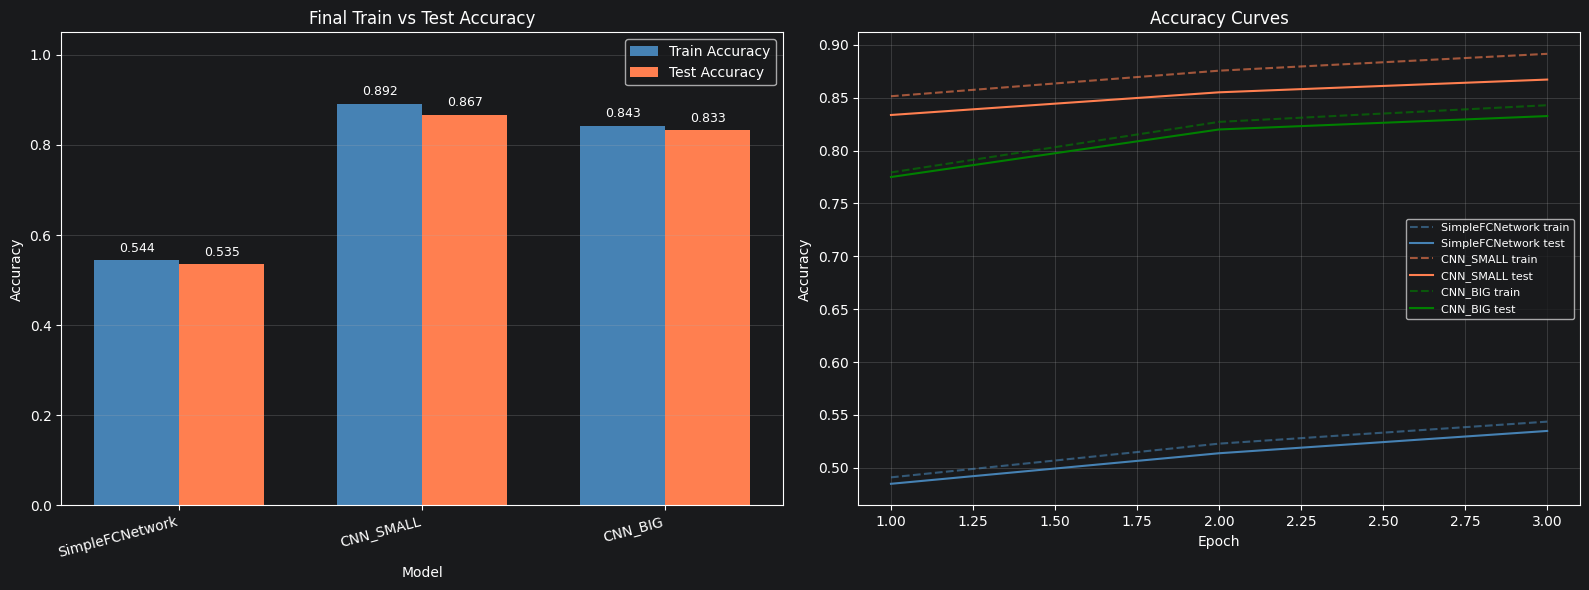

In [27]:
def full_training_loop_and_store_accuracies(ModelType, train_loader, test_loader, num_epochs=10, path='saved_accuracies/'):
    """
    Creates an instance of the model, runs a full training loop while recording
    accuracies, and saves them to disk.
    """

    num_classes = len(label_names)
    if ModelType == SimpleFCNetwork:
        model = ModelType(input_size=28*28,hidden_size=64, num_classes=num_classes)
    else:
        model = ModelType(num_classes=num_classes)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    model, train_accs, test_accs = train_num_epochs_and_track_accuracies(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        num_epochs=num_epochs,
        with_checkpointing=False
    )
    os.makedirs(path, exist_ok=True)
    np.save(os.path.join(path, f'{ModelType.__name__}_accuracies.npy'),{'train': train_accs, 'test': test_accs})
    return model, train_accs, test_accs




def load_accuracies_and_create_plots(model_name, accuracies=None, path='saved_accuracies/'):
    """
    Loads previously stored accuracies and creates training curve plots.
    """
    if accuracies is None:
        load_path = os.path.join(path,f'{model_name}_accuracies.npy')
        data = np.load(load_path, allow_pickle=True).item()
        train_accs = data['train']
        test_accs = data['test']
    else:
        train_accs = accuracies['train']
        test_accs= accuracies['test']
    epochs = range(1, len(train_accs) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_accs, label='Train Accuracy', linewidth=2)
    plt.plot(epochs, test_accs,label='Test Accuracy', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training Curve-{model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return train_accs, test_accs


def comparison_plot(accuracies):
    """
    Creates a bar plot comparing the final train and test accuracies of multiple models.

    Args:
        accuracies: List of dicts, each with keys:
            - 'model_name': str
            - 'train': list of train accuracies per epoch
            - 'test':  list of test  accuracies per epoch
    """
    model_names = [entry['model_name'] for entry in accuracies]
    final_train = [entry['train'][-1] for entry in accuracies]
    final_test = [entry['test'][-1] for entry in accuracies]

    x = np.arange(len(model_names))
    width = 0.35

    fig, axes = plt.subplots(1,2,figsize=(16, 6))

    # first plot to show the accuracies as bars
    ax = axes[0]
    bars_train = ax.bar(x-width/2, final_train, width, label='Train Accuracy',color='steelblue')
    bars_test  = ax.bar(x+width/2, final_test, width, label='Test Accuracy', color='coral')
    for bar in list(bars_train) + list(bars_test):
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)
    ax.set_xlabel('Model')
    ax.set_ylabel('Accuracy')
    ax.set_title('Final Train vs Test Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    # second plot to show accuracy curves per epoch
    ax = axes[1]
    colors = ['steelblue','coral', 'green']
    for i, entry in enumerate(accuracies):
        epochs = range(1, len(entry['train']) + 1)
        ax.plot(epochs, entry['train'], linestyle='--', color=colors[i], alpha=0.6, label=f"{entry['model_name']} train")
        ax.plot(epochs, entry['test'],  linestyle='-', color=colors[i], label=f"{entry['model_name']} test")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy Curves')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


all_accuracies = []
for ModelType in [SimpleFCNetwork, CNN_SMALL, CNN_BIG]:
    print(f"\n{'='*40}\nTraining {ModelType.__name__}\n{'='*40}")
    model, train_accs, test_accs = full_training_loop_and_store_accuracies(ModelType, train_loader, test_loader, num_epochs=3)
    all_accuracies.append({
        'model_name': ModelType.__name__,
        'train': train_accs,
        'test':  test_accs
    })

comparison_plot(all_accuracies)



### 🖊️📜 (400 words max)

Discuss here the structure of the implemented neural network architectures and analyse the plots you created in order to compare their performances.  

## Part 3: Hyperparameter Optimisation Study
In this task, you will learn how to perform a hyperparameter optimisation study. Training a neural network involves different parameters, like batch size, learning rate, weight decay etc. Those parameters have to be set before the training and their choice determines if the network converges at all and how well the network performs in the end. 

There are various ways to perform hyperparameter optimisation, but the basic idea is to search the best possible combination of parameters in terms of network performance. For that a network can be trained for a few epochs for each parameter combination and evaluated. The best performing combination should then be chosen and the network can be trained for the total desired amount of epochs with the optimized hyperparameters. Perform the hyperparameter optimisation for the **big CNN** model with 25 trials! You are allowed to take a section of the train set as a validation set for the hyperparameter optimisation!

We will not focus on the theory (grid search, random search, bayesian optimisation) behind it, the scope of this task is that you have performed HPO at least once in your studies and that you know how it practically works.

In [ ]:
# Don't forget to do a train/validation/test split
from torch.utils.data import random_split

def objective(trial):
    """
    Objective function for hyperparameter optimization using Optuna. It suggests a set of hyperparameters, initializes model and optizer, trains the model for a fixed number of epochs and returns the validation accuracy.

    Args:
        trial (optuna.trial.Trial): A specific trial object provided by the
            Optuna study to suggest hyperparameters and report progress.

    Returns:
        float: The final validation accuracy of the model, used by Optuna
            to evaluate the quality of the suggested hyperparameters.
    """
    raise NotImplementedError("Implement this.")

In [ ]:
raise NotImplementedError("Execute the optuna study here.")

Now that you have found the best parameters for the network to train, use them to train the network for 10 epochs and analyse it in your report. Compare the network accuracy you achieve now with the accuracy you previously achieved!

In [ ]:
raise NotImplementedError(
    "Use the best parameters from the optuna hyperparameters study and train the neural network with those."
)

### 🖊️📜 (250 words max)

Explain here how you implemented the hyperparameter optimization study, which hyperparameter search space you chose, how the newly obtained model compares to the previous models and why and what might be the pitfalls of HPO.

## Part 4: Explainable AI

In this task, you will learn about Explainable AI. This is a branch of AI that seeks to develop methods that help us explain why AI models behave as they do. For this assignment, we will focus on probing, although there are many other XAI methods. Probing is a technique that seeks to determine whether a particular concept is "stored" at a particular layer in a model. For example, in a model as  any of the ones in this assingment, we may want to determine if this model stores information on whether this character is a number or a letter, when presented with a character. While the final task does not differentiate between numbers and letters, it is possible that the model still makes this distinction somewhere througout its layers. In order to discover this, we can follow this process:

- Feed the model EMNIST images and let it perform inference, but record the activations of the model at each of its layers for each image shown. Do this to create train and test activation sets and save them.
- Train a very simple model, which we call a probe, with the input being the activations of the original model at a particular layer, and the output being whether this character is a number or a letter. The model should be very simple (e.g linear regression).
- Test this probe on the test set of activations, and observe how well the probe is at predicting whether a character is a number or a letter by only looking at the activations at a particular layer.
- Train another probe at the same layer, but in this case, instead of making it predict whether a character is a number or a letter, make it predict a random meaningless task with the same structure as the standard task (so it should also be binary and have similar label quantity proportions. For example, here there are two reasonable control tasks: first one is give each character a number/letter label randomly, so all "a"s become a number, "b"s a letter, "7"s a letter, etc. Second one is give each image a number/letter label randomly regardless of its character). Then, test this control probe (the test set should also use control labels generated in the same random way)
- If the standard probe performs better than the control probe, this indicates that the activations at this layer contain some information that encodes whether the character was a letter or a number.
- We do the same thing for all layers to observe at what layers this information is most clearly encoded.

Your task for this part of the assignment is to perform a small probing study with the **big CNN model**. You need to set up the code infrastructure to carry out probing experiments, and report the results along with a reflection on what these results may mean. **Remember to also create a control task for each of these tasks**; this is very important, and for each task you should think carefully about the way the control task labels should be created. To ensure a reasonable computation time, you should generate the activations of **at most** 2560 images per split to run your study. These are the specific tasks you need to implement:

### Task 1

Make a probe that predicts if the image contains a letter or a number.

### Task 2

Make a probe that predicts the amount of closed segments in the image. For example, "9" has one closed circle, "8" has two, "a" has one, and "T" has zero. Since this may depend on the font (e.g "g" can have 1 or 2 depending on the font), determining the number of segments for every single image in the EMNIST dataset is challenging. To simplify the task, you can assume every image associated with each of these characters has the same number of closed segments and use the following list:

- 1 closed segment: 0, 4, 6, 9, a, b, d, e, o, p, q, A, D, O, P, Q, R
- 2 closed segments: 8, g, B
- 0 closed segments: everything else

Take into account that EMNIST balance merges some characters that are considered potentially indistinguishable in written form, such as "o" and "O".

### Task 3

Make a probe that performs the same task as the model it is built on top of (predict the specific character class present in the image).

### Task 4

Come up with a new probing task and implement it. Explain why this task is interesting.

In [ ]:
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from random import seed
from typing import Any, Callable
from pathlib import Path

# Create ActivationLoader class, which lets us store activations from models, save them, and load them from files.
class ActivationLoader:
    """Loads a model and extracts activations from its layers"""

    def __init__(self) -> None:
        raise NotImplementedError("Implement this.")

    def generate_activations(
        self,
        dataloader: t.utils.data.DataLoader,
        split: str,
        save_to_disk: bool,
        amount_to_generate: int,
    ) -> None:
        """
        Extract activations from all layers by running forward passes through the dataloader.

        Args:
            dataloader: DataLoader with images and labels for activation extraction
            split: Either "train" or "test" for naming saved files
            save_to_disk: Whether to save activations to disk
            amount_to_generate: Maximum number of samples to extract activations for
        """
        raise NotImplementedError("Implement this.")


class Probe:
    """
    Probe for classification tasks on neural network activations. Should use a linear 
    model (e.g linear regression)
    """

    def __init__(self, d_in: int, d_out: int, classes: list) -> None:
        raise NotImplementedError("Implement this.")


def create_probe_from_data(acts: t.Tensor, labels: t.Tensor) -> "Probe":
    """
    Create and train a Probe.

    Args:
        acts: Activation tensor of shape (num_samples, activation_dim)
        labels: Label tensor of shape (num_samples,) for classification targets

    Returns:
        Trained Probe instance ready for inference
    """
    raise NotImplementedError("Implement this.")


def generate_all_labels_of_probing_tasks(original_labels):
    """
    Implement a function that takes in the original labels of the dataset,
    and based on these creates the labels required for every probing task.
    Make sure to include the control tasks too.
    """
    raise NotImplementedError("Implement this.")


def plot_metrics() -> None:
    """
    Plot the accuracy (or precision, recall, f1 or whichever metric you see fit) 
    of the probe predictions over the layers (one line for the probe trained on 
    the standard task. Another line for the probe trained on the control task)
    """
    raise NotImplementedError("Implement this.")

### 🖊️📜 (200 words max)
Answer the following:

- Why is a control task necessary? Couldn't we just do the standard task?
- Why do we use very simple models as probes? Wouldn't a neural network with many layers be better?
- If a probing experiment gives positive results, does this necessarily mean that the model actually uses this information during inference? Why or why not?
- Why would we ask you to do a probing task that is the same as the original task (character classification)? Does this probing task tell us anything new compared to just observing the original model's performance?

### 🖊️📜 (50 words max)

What probe did you make for task 4? What was the idea behind it?

### 🖊️📜 (300 words max)

Make a small report on your results. What do you observe looking at the graphs? Can you explain why your curves may look like this? What do they tell you about whether (and if so, at what layers) the model stores any of the concepts we were trying to probe for?